In [1]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
import pandas as pd

In [18]:
# Transfer Functions

#First order : 1/(s+1)
G1 = ctrl.TransferFunction([1], [1, 1])

# Second order : 1/(s+1)(s+2)
G2 = ctrl.TransferFunction([1], [1, 3, 2])

# Higher Order

# 1/(s+1)(s+2)(s+3)
G3 = ctrl.TransferFunction([1], [1, 8, 11, 6])

# 1/(s+1)(s+2)(s+3)(s+4)
G4 = ctrl.TransferFunction([1], [1, 10, 35, 50, 24])

# 1/(s-1)(s+2)(s+3)
G5 = ctrl.TransferFunction([1], [1, 4, 1, -6])

# (s+2)/(s-1)(s-2)(s+3)(s+4)
G6 = ctrl.TransferFunction([1, 2], [1, 4, -7, -22, 24])

systems = {
    "1/(s+1)": G1,
    "1/(s+1)(s+2)": G2,
    "1/(s+1)(s+2)(s+3)": G3,
    "1/(s+1)(s+2)(s+3)(s+4)": G4,
    "1/(s-1)(s+2)(s+3)" : G5,
    "(s+2)/(s-1)(s-2)(s+3)(s+4)": G6

}

In [19]:
def is_stable(G, Kp, Ki, Kd) :
    # PID controller
    C = ctrl.TransferFunction(
        [Kd, Kp, Ki],
        [1, 0]
    )

    # Unity feedback
    T = ctrl.feedback(C * G, 1)

    # Closed-loop poles
    poles = ctrl.poles(T)

    # Stability condition
    return np.all(np.real(poles) < 0)

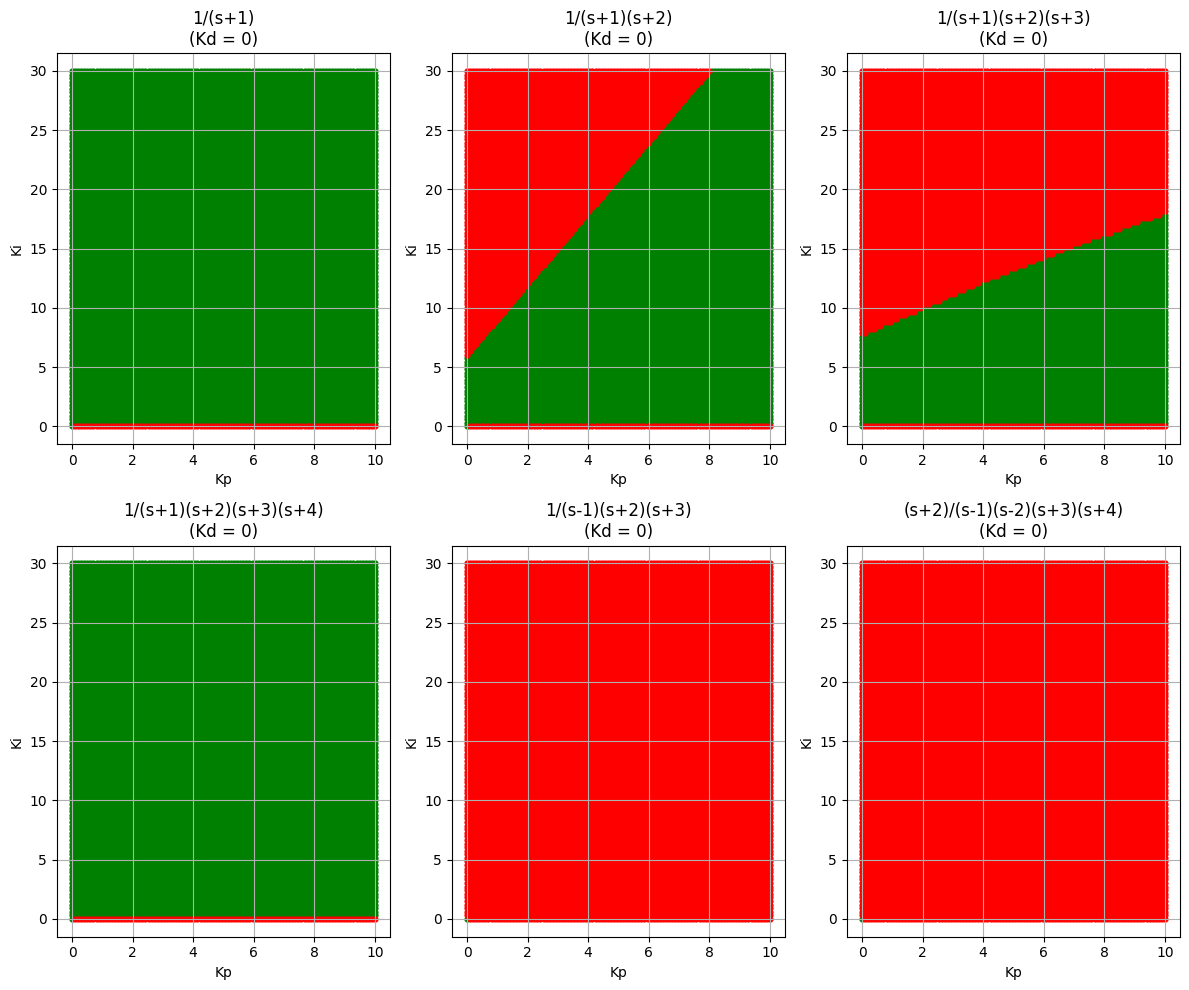

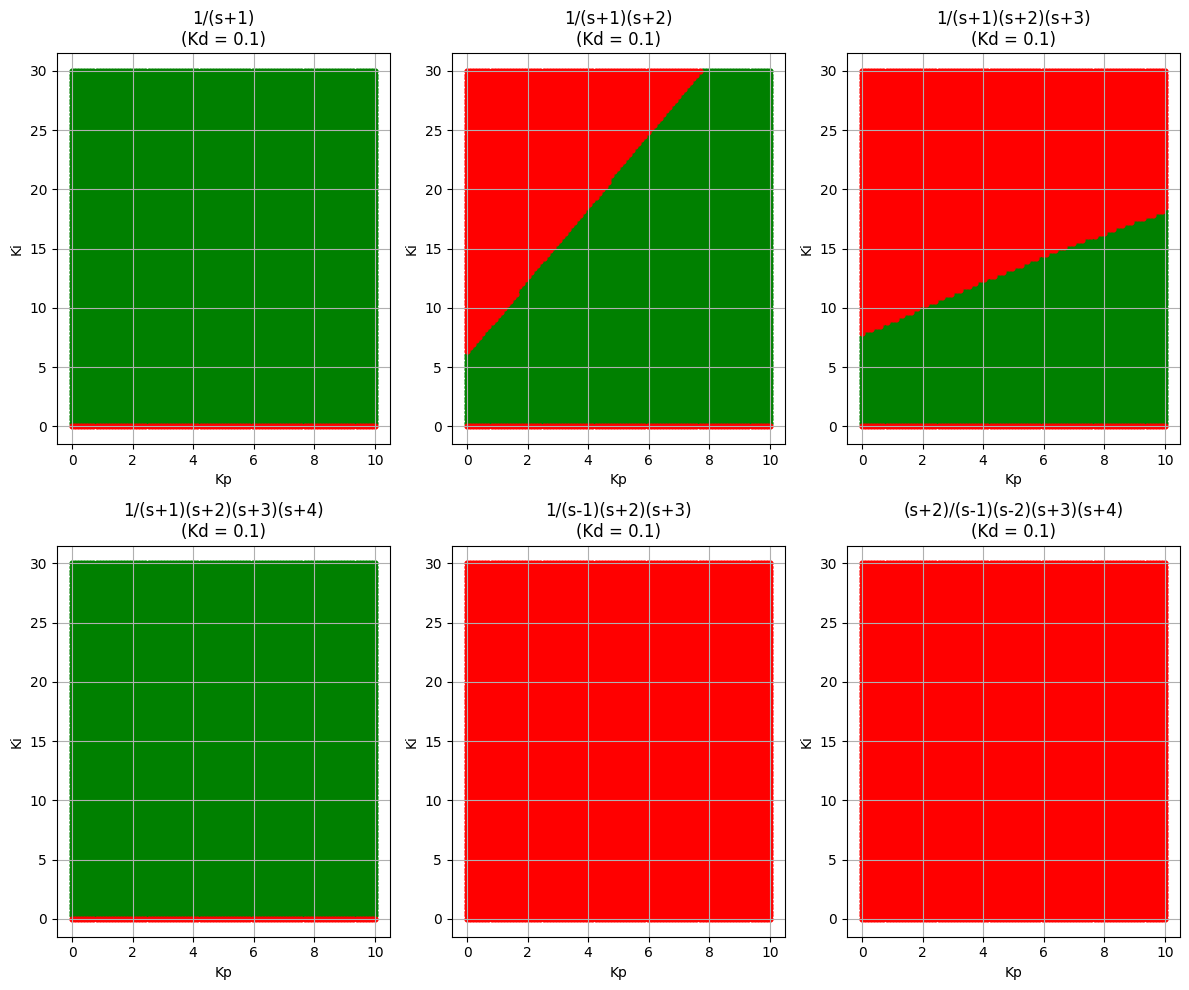

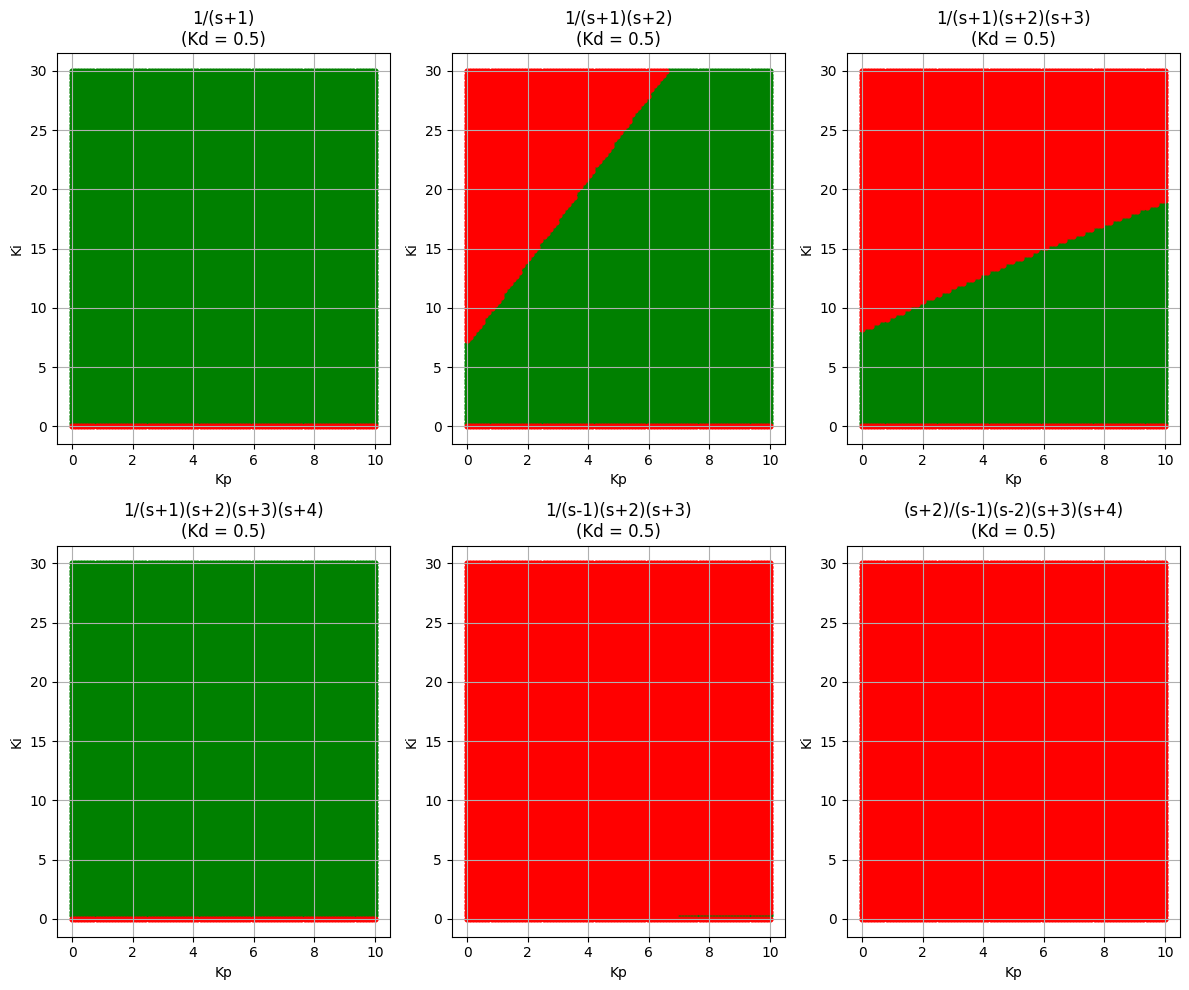

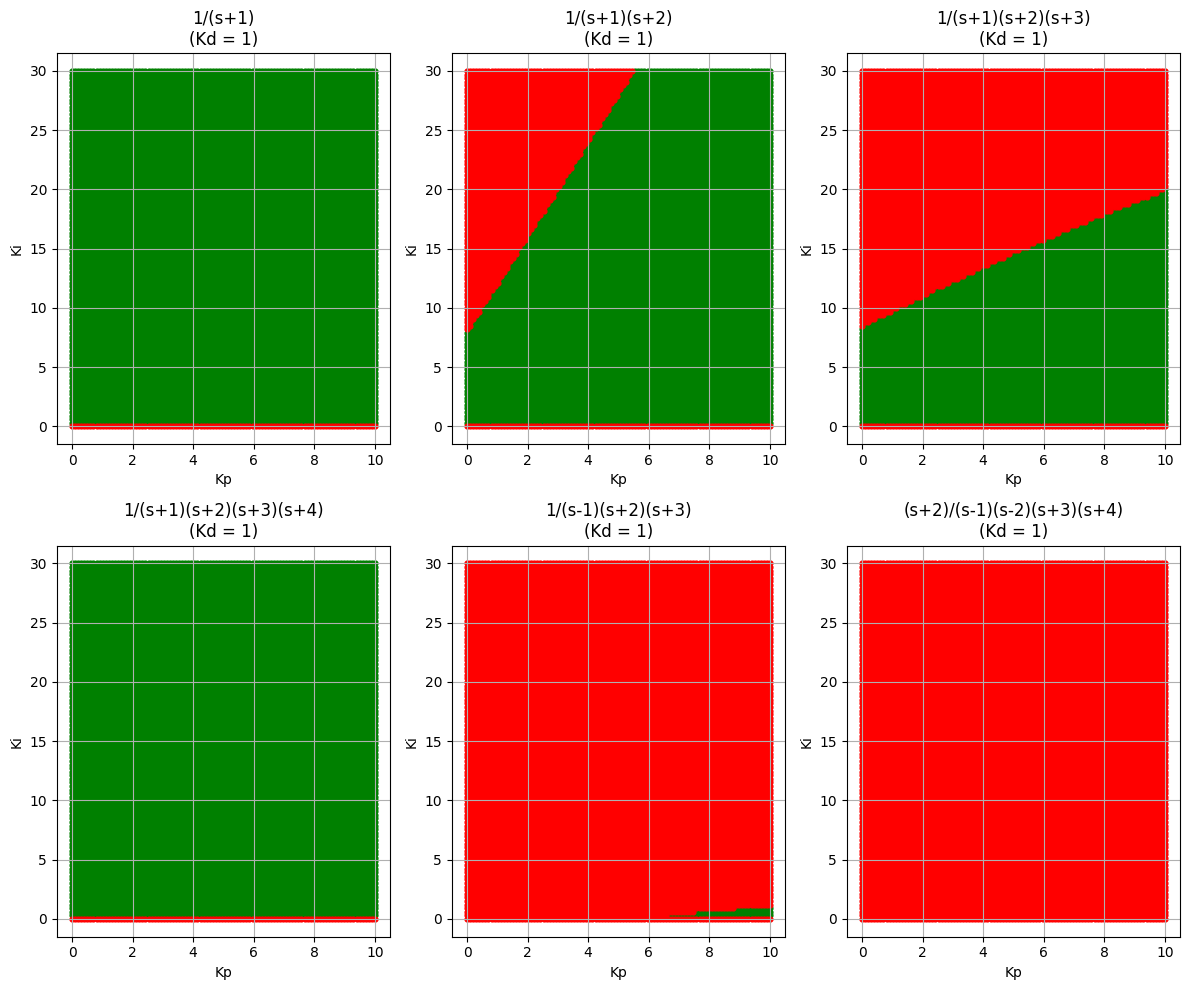

In [20]:
# Kp vs Ki stability plot
def plot(Kd, Kp_values, Ki_values): 
    fig, axes = plt.subplots(2, 3, figsize=(12, 10))

    axes = axes.flatten()

    for ax, (name, G) in zip(axes, systems.items()):

        stable_x = []
        stable_y = []

        unstable_x = []
        unstable_y = []

        for Kp in Kp_values:
            for Ki in Ki_values:

                if is_stable(G, Kp, Ki, Kd):
                    stable_x.append(Kp)
                    stable_y.append(Ki)
                else:
                    unstable_x.append(Kp)
                    unstable_y.append(Ki)

        ax.scatter(
            stable_x,
            stable_y,
            color="green",
            s=12,
            label="Stable"
        )

        ax.scatter(
            unstable_x,
            unstable_y,
            color="red",
            s=12,
            label="Unstable"
        )

        ax.set_title(f"{name}\n(Kd = {Kd})")
        ax.set_xlabel("Kp")
        ax.set_ylabel("Ki")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

Kd_values = [0, 0.1, 0.5, 1]
Ki_values = np.linspace(0, 30, 100)
Kp_values = np.linspace(0, 10, 100)

for Kd in Kd_values:
    plot(Kd, Kp_values, Ki_values)